In [ ]:
"""
Author:
- Duilio Fonseca-Gallardo
- Montana State University
- Email: duilio.fonseca@anori.cl
- GitHub: https://github.com/duiliofg

Script Title: Workflow for the hyperspectral to Landsat reflectance comparison

Description:
Orchestrates the full processing chain by running scripts 1 to 9 of this folder for
each study site (Onion Park, Sodankyla, CARC and Greenland): hypercube conversion to
GeoTIFF, Landsat RSR simulation, grid extraction, reflectance comparison and plots, CNN
training and classification, and reflectance statistics by surface type.

Requirements:
- Python 3.x
- Libraries: glob, matplotlib, pandas, seaborn and the modules in this folder
"""

#### Call functions

In [1]:
# Execute full HSI-to-Landsat comparison and classification pipeline
# Each script performs a sequential step in the analysis workflow:
# 1. Convert HSI to GeoTIFF
# 2. Simulates Landsat RSR response using Pika L and Pika IR-L hyperspectral data.
# 3. Extract Landsat grid
# 4. Compare reflectance (HSI vs Landsat)
# 5. Generate comparison plots
# 6. Train CNN classifier
# 7. Apply CNN to all HSI cubes
# 8. Compute reflectance from HSI based on surface type masks or classified pixels
# 9. Compute reflectance from RSR-corrected HSI based on surface type masks or classified pixels

%run 1_hsi_to_geotiff.py
%run 2A_rsr_pika_L.py
%run 2B_rsr_pika_IRL.py
%run 3_extract_landsat_grid.py
%run 4_compare_landsat_hsi.py
%run 5a_compare_plot.py
%run 5b_compare_plot_IRL.py
%run 6_training_CNN.py
#%run 7_run_CNN_all_hsi.py
#%run 8_reflectance_HSI.py
%run 7_run_CNN_all_hsi_greenland.py
%run 8_reflectance_HSI_greenland.py
%run 9b_reflectance_band.py

Loading hypercube_to_geotiff
Loading simulate_landsat_bands
Loading extract_crs_and_transform_from_hdr
Loading create_grid_from_raster
Loading multiband_reflectance_differences
Loading plot_reflectance_and_differences_by_pixel_type
Loading plot_reflectance_and_differences_by_pixel_type_IRL_small_variants


2025-07-25 09:28:43.635544: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-25 09:28:43.890039: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-07-25 09:28:44.919474: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-07-25 09:28:47.622268: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


Loading train_strict_cnn_from_polygons
Loading classify_and_vectorize_cubes
Loading compute_reflectance_statistics
[INFO] Loaded compute_reflectance_statistics_rsr


In [4]:
# Directories for Onion Park, MT, US.
# Post processing for reflectance
reflectance_hypercube_pl= '/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/01_hypercubes/01_reflectance'
reflectance_hypercube_pirl= '/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/01_hypercubes/01_reflectance'
reflectance_raster_pl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance'
reflectance_raster_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/01_reflectance'
reflectance_rsr_pl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/02_reflectance_rsr_bands'
reflectance_rsr_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/02_reflectance_rsr_bands'
output_rsr="/path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion"
place='Onion'
landsat_path = "/path/to/snow_albedo/01_input/02_landsat_image/LC08_038028_20240420_Onion.tif"
landsat_filename = "LC08_038028_20240420_Onion"
grid_raw = "/path/to/snow_albedo/01_input/06_grids/LC08_038028_20240420_Onion_raw.gpkg"
grid_processed="/path/to/snow_albedo/01_input/06_grids/20240220_ONION_PARK_v2.gpkg"

# Pixel Classification
training_polygons_pl="/path/to/snow_albedo/03_incremental/03_training_data/20240420_ONION_PARK/20240420_Onion-park_PIL.gpkg"
reflectance_raster_pl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance'
training_polygons_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240420_ONION_PARK/20240420_Onion-park_PIRL.gpkg"
reflectance_raster_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/01_reflectance'
output_training_pl="/path/to/snow_albedo/03_incremental/03_training_data/20240420_ONION_PARK/pika_L"
output_training_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240420_ONION_PARK/pika_IRL"
output_classification_pl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240420_Onion_Park/pika_L"
output_classification_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240420_Onion_Park/pika_IRL"
output_classification_product_pl="/path/to/snow_albedo/04_products/02_classificated_reflectance/20240420_Onion_Park/pika_L"
output_classification_product_pirl="/path/to/snow_albedo/04_products/02_classificated_reflectance/20240420_Onion_Park/pika_IRL"
gpkg_classified_pl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240420_Onion_Park/pika_L/gpkg"
gpkg_classified_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240420_Onion_Park/pika_IRL/gpkg"

In [15]:
# Directories for Sodankyla, Finland.
# Post processing for reflectance
reflectance_hypercube_pirl= '/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Sodankyla/20240403_PIRL/01_hypercubes/01_reflectance'
reflectance_raster_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Sodankyla/20240403_PIRL/02_geotiff/01_reflectance'
reflectance_rsr_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Sodankyla/20240403_PIRL/02_geotiff/02_reflectance_rsr_bands'
output_rsr="/path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240403_Sodankyla"
place='Sodankyla'
landsat_path = "/path/to/snow_albedo/01_input/02_landsat_image/LC09_192012_20240403_sodankyla.tif"
landsat_filename = "LC09_192012_20240403_sodankyla"
grid_raw = "/path/to/snow_albedo/01_input/06_grids/LC09_192012_20240403_Sodankyla_raw.gpkg"
grid_processed="/path/to/snow_albedo/01_input/06_grids/20240403_Sodankyla_v2.gpkg"

# Pixel Classification
training_polygons_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240403_Sodankyla/20240403_Sodankyla_pika_IRL.gpkg"
output_training_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240403_Sodankyla/pika_IRL"
output_classification_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240403_Sodankyla/pika_IRL"
output_classification_product_pirl="/path/to/snow_albedo/04_products/02_classificated_reflectance/20240403_Sodankyla/pika_IRL"
gpkg_classified_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240403_Sodankyla/pika_IRL/gpkg"

In [17]:
# Directories for CARC, MT, US
# Post processing for reflectance
reflectance_hypercube_pirl= '/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_CARC_MT/20240216_CARC_PIRL/01_hypercube/01_reflectance'
reflectance_raster_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_CARC_MT/20240216_CARC_PIRL/02_geotiff/01_reflectance'
reflectance_rsr_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_CARC_MT/20240216_CARC_PIRL/02_geotiff/02_reflectance_rsr_bands'
output_rsr="/path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240216_CARC"
place='CARC'
landsat_path = "/path/to/snow_albedo/01_input/02_landsat_image/LC08_038027_20240216_CARC.tif"
landsat_filename = "LC08_038027_20240216_CARC"
grid_raw = "/path/to/snow_albedo/01_input/06_grids/LC08_038027_20240216_CARC_raw.gpkg"
grid_processed="/path/to/snow_albedo/01_input/06_grids/20240216_CARC_grid.gpkg"

# Pixel Classification
training_polygons_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240216_CARC/20240216_CARC_PIRL.gpkg"
output_training_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240216_CARC/pika_IRL"
output_classification_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240216_CARC/pika_IRL"
output_classification_product_pirl="/path/to/snow_albedo/04_products/02_classificated_reflectance/20240216_CARC/pika_IRL"
gpkg_classified_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240216_CARC/pika_IRL/gpkg"

In [2]:
# Directories for Greenland
# Post processing for reflectance
reflectance_hypercube_pirl= '/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/01_hypercubes/02_reflectance'
reflectance_raster_pirl='/path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance'
place='Greenland'

# Pixel Classification
training_polygons_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240630_greenland/20240630_greenland.gpkg"
output_training_pirl="/path/to/snow_albedo/03_incremental/03_training_data/20240630_greenland/pika_IRL"
output_classification_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240630_greenland/pika_IRL"
output_classification_product_pirl="/path/to/snow_albedo/04_products/02_classificated_reflectance/20240630_greenland/pika_IRL"
gpkg_classified_pirl="/path/to/snow_albedo/03_incremental/04_classified_rasters/20240630_greenland/pika_IRL/gpkg"

#### Part 1 : Calculating reflectance difference

In [5]:
# 1. Convert the hypercube to a geotiff
# 1.1 Pika L
process_all_hypercubes(reflectance_hypercube_pl,reflectance_raster_pl,'PIL',place)
# 1.2 Pika IR-L
#process_all_hypercubes(reflectance_hypercube_pirl,reflectance_raster_pirl,'PIRL',place)

GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_20_PIL.tiff
GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_53_PIL.tiff
GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_30_PIL.tiff
GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_43_PIL.tiff
GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_62_PIL.tiff
GeoTIFF file saved successfully: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_r

In [6]:
# 2. HSI reflectance to Landsat emulated reflectance
# 2.1 Pika L
import glob

rsr_csv_dirs = {8: "/path/to/snow_albedo/01_input/08_RSR/LANDSAT8",
                9: "/path/to/snow_albedo/01_input/08_RSR/LANDSAT9"} # Don't change it
bands_info = {
    'B1': (430, 450),
    'B2': (450, 515),
    'B3': (525, 600),
    'B4': (630, 680),
    'B5': (845, 885)
}

cube_paths = glob.glob(os.path.join(reflectance_hypercube_pl, '*.bip.hdr'))

for cube_hdr_path in cube_paths:
    cube_base_name = os.path.basename(cube_hdr_path).replace('.bip.hdr', '')
    for satellite, rsr_csv_dir in rsr_csv_dirs.items():
        # output_dir = os.path.join(reflectance_rsr_pl, f"landsat{satellite}")
        # os.makedirs(output_dir, exist_ok=True)

        # ✅ Instead, pass the *root* output folder to the function:
        simulate_landsat_bands(
            cube_path=cube_hdr_path,
            rsr_csv_dir=rsr_csv_dir,
            output_root_dir=reflectance_rsr_pl,  # <--- the root folder
            basename=cube_base_name,
            bands_info=bands_info,
            satellite=satellite
        )

print("Processing completed for all hypercubes.")

✅ 20240420_onion_crns_Pika_L_20-Georectify Airborne Datacube - Landsat 8
   RSR saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/02_reflectance_rsr_bands/landsat8/20240420_onion_crns_Pika_L_20-Georectify Airborne Datacube_Landsat8_RSR.tif
   AVG saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/02_reflectance_rsr_bands/avg/20240420_onion_crns_Pika_L_20-Georectify Airborne Datacube_Landsat8_AVG.tif
✅ 20240420_onion_crns_Pika_L_20-Georectify Airborne Datacube - Landsat 9
   RSR saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/02_reflectance_rsr_bands/landsat9/20240420_onion_crns_Pika_L_20-Georectify Airborne Datacube_Landsat9_RSR.tif
   AVG saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/02_reflectance_rsr_bands/avg/20240420_onion_crns_Pika_L_20-Georectify

In [5]:
# 2.2 Pika IR-L

os.makedirs(reflectance_rsr_pirl, exist_ok=True)

rsr_csv_dirs = {8: "/path/to/snow_albedo/01_input/08_RSR/LANDSAT8",
                9: "/path/to/snow_albedo/01_input/08_RSR/LANDSAT9"} 

cube_paths = glob.glob(os.path.join(reflectance_hypercube_pirl, '*.bip.hdr'))

for cube_hdr_path in cube_paths:
    cube_base_name = os.path.basename(cube_hdr_path).replace('.bip.hdr', '')
    for satellite, rsr_csv_dir in rsr_csv_dirs.items():
        simulate_pika_irl_band6(
            cube_path=cube_hdr_path,
            rsr_csv_dirs=rsr_csv_dir,
            output_root_dir=reflectance_rsr_pirl,
            basename=cube_base_name,
            satellite=satellite
        )

print('Processing completed for all Pika IR-L hypercubes.')

✅ Landsat 8 Band 6 processed for 20240420_onion_crns_Pika IR L_3-Reflectance from Raw Data and Downwelling Irradiance Spectrum
   - RSR saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/02_reflectance_rsr_bands/landsat8/20240420_onion_crns_Pika IR L_3-Reflectance from Raw Data and Downwelling Irradiance Spectrum_Landsat8_B6_RSR.tif
   - AVG saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/02_reflectance_rsr_bands/avg/20240420_onion_crns_Pika IR L_3-Reflectance from Raw Data and Downwelling Irradiance Spectrum_Landsat8_B6_AVG.tif
✅ Landsat 9 Band 6 processed for 20240420_onion_crns_Pika IR L_3-Reflectance from Raw Data and Downwelling Irradiance Spectrum
   - RSR saved to: /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIRL/02_geotiff/02_reflectance_rsr_bands/landsat9/20240420_onion_crns_Pika IR L_3-Reflectance from Raw Data and Downw

In [9]:
# 3. Extract grid from Landsat Imagery
create_grid_from_raster(landsat_path, grid_raw)


Grid generated and saved to /path/to/snow_albedo/01_input/06_grids/LC09_192012_20240403_Sodankyla_raw.gpkg


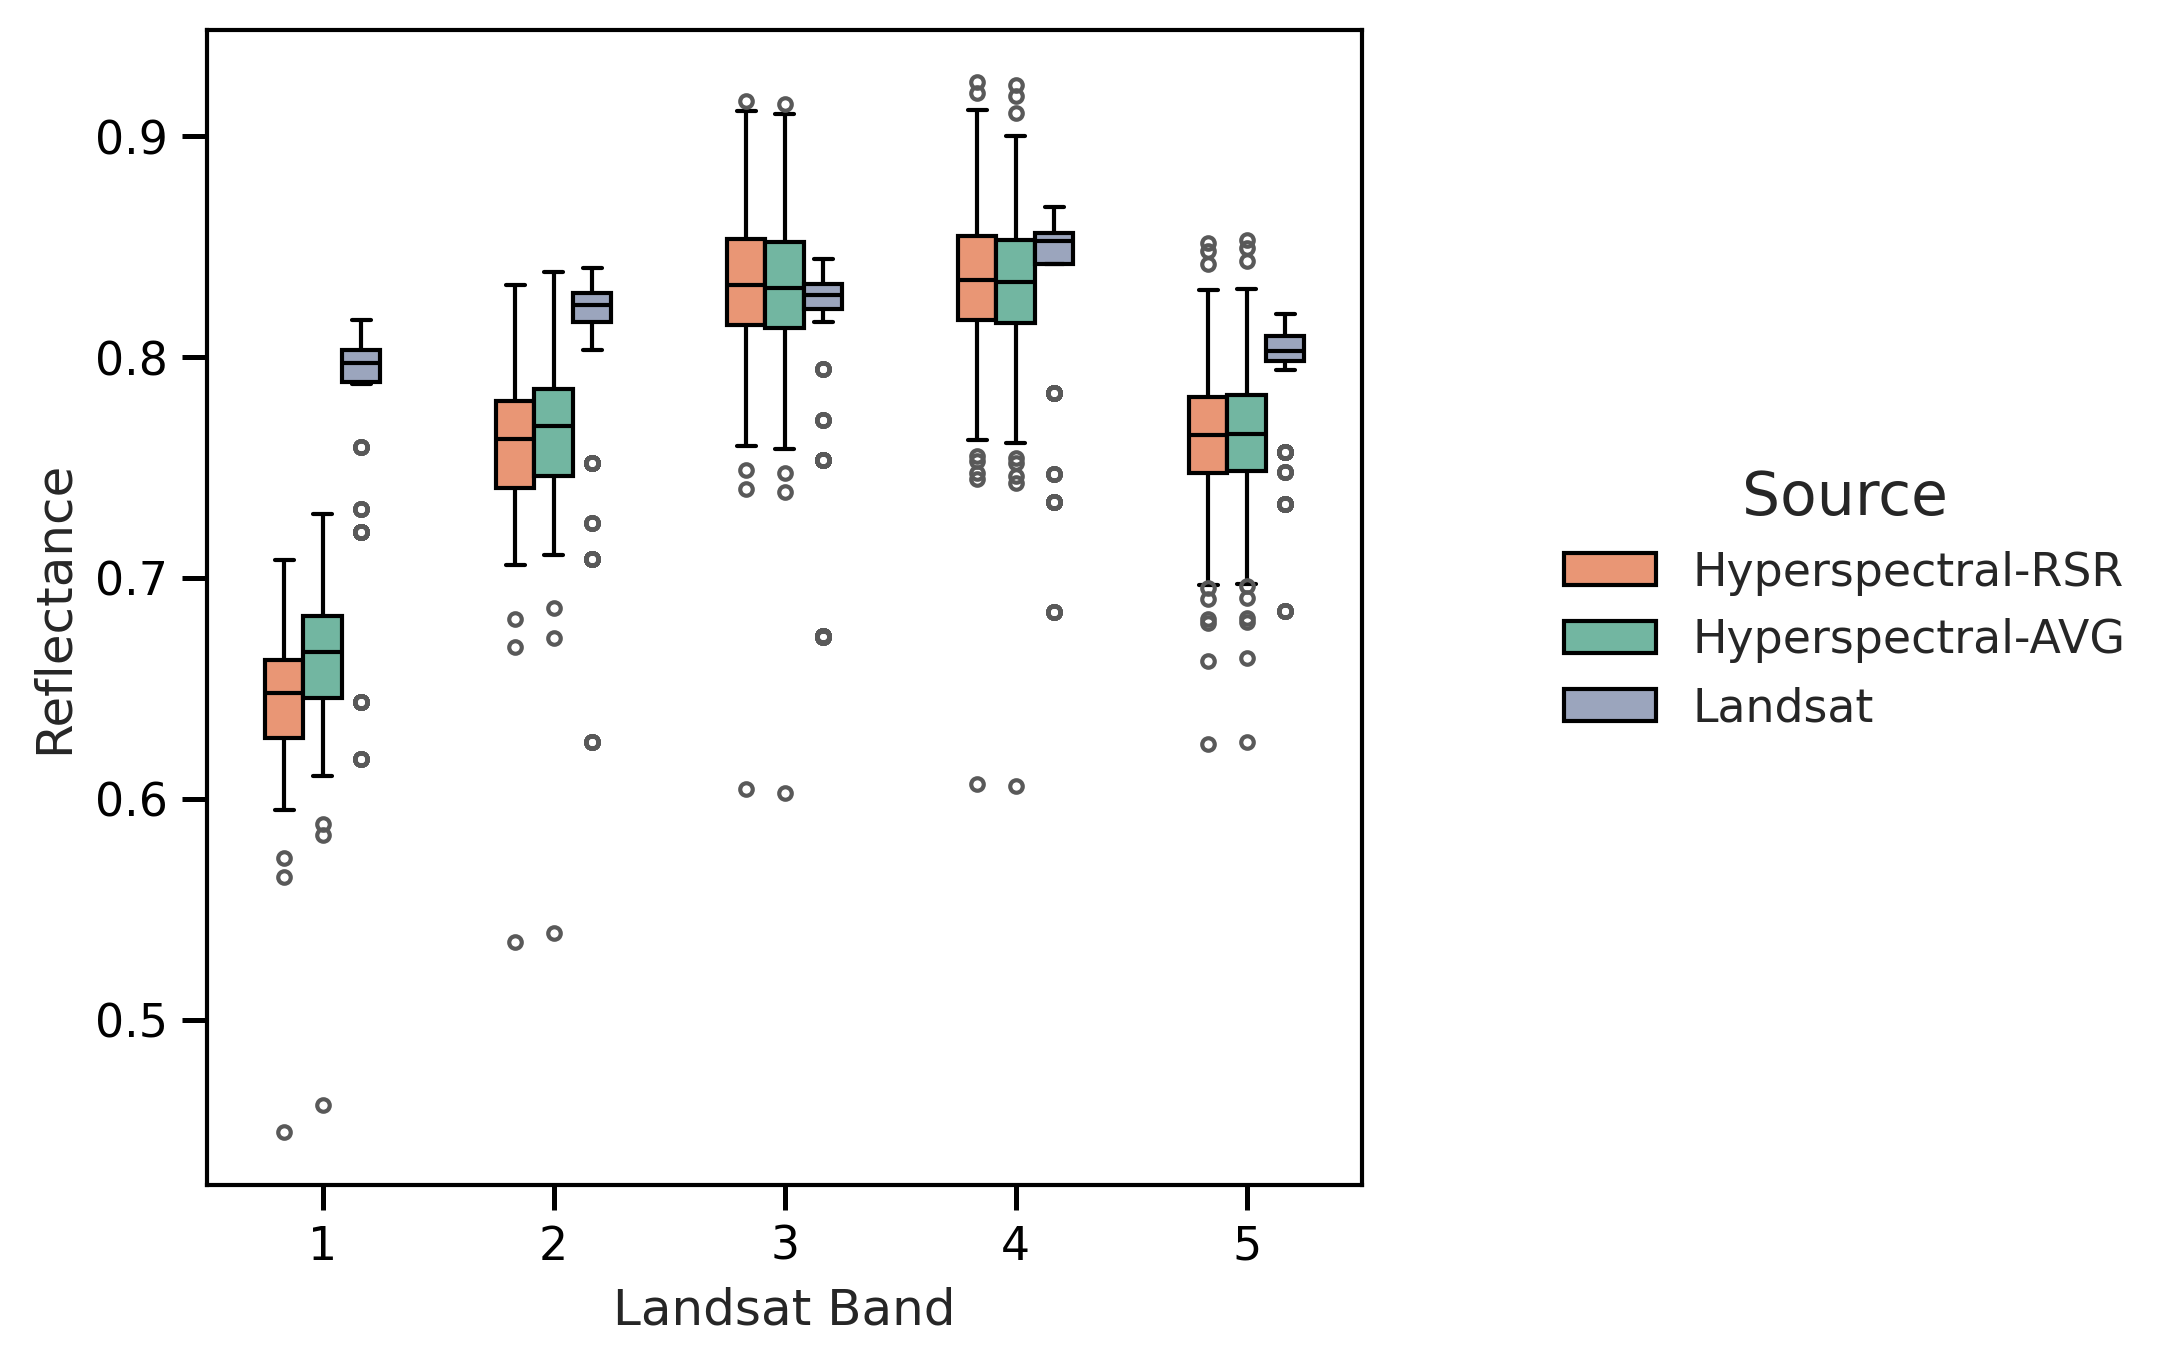

✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/pika_L/reflectance_comparison_snow.png


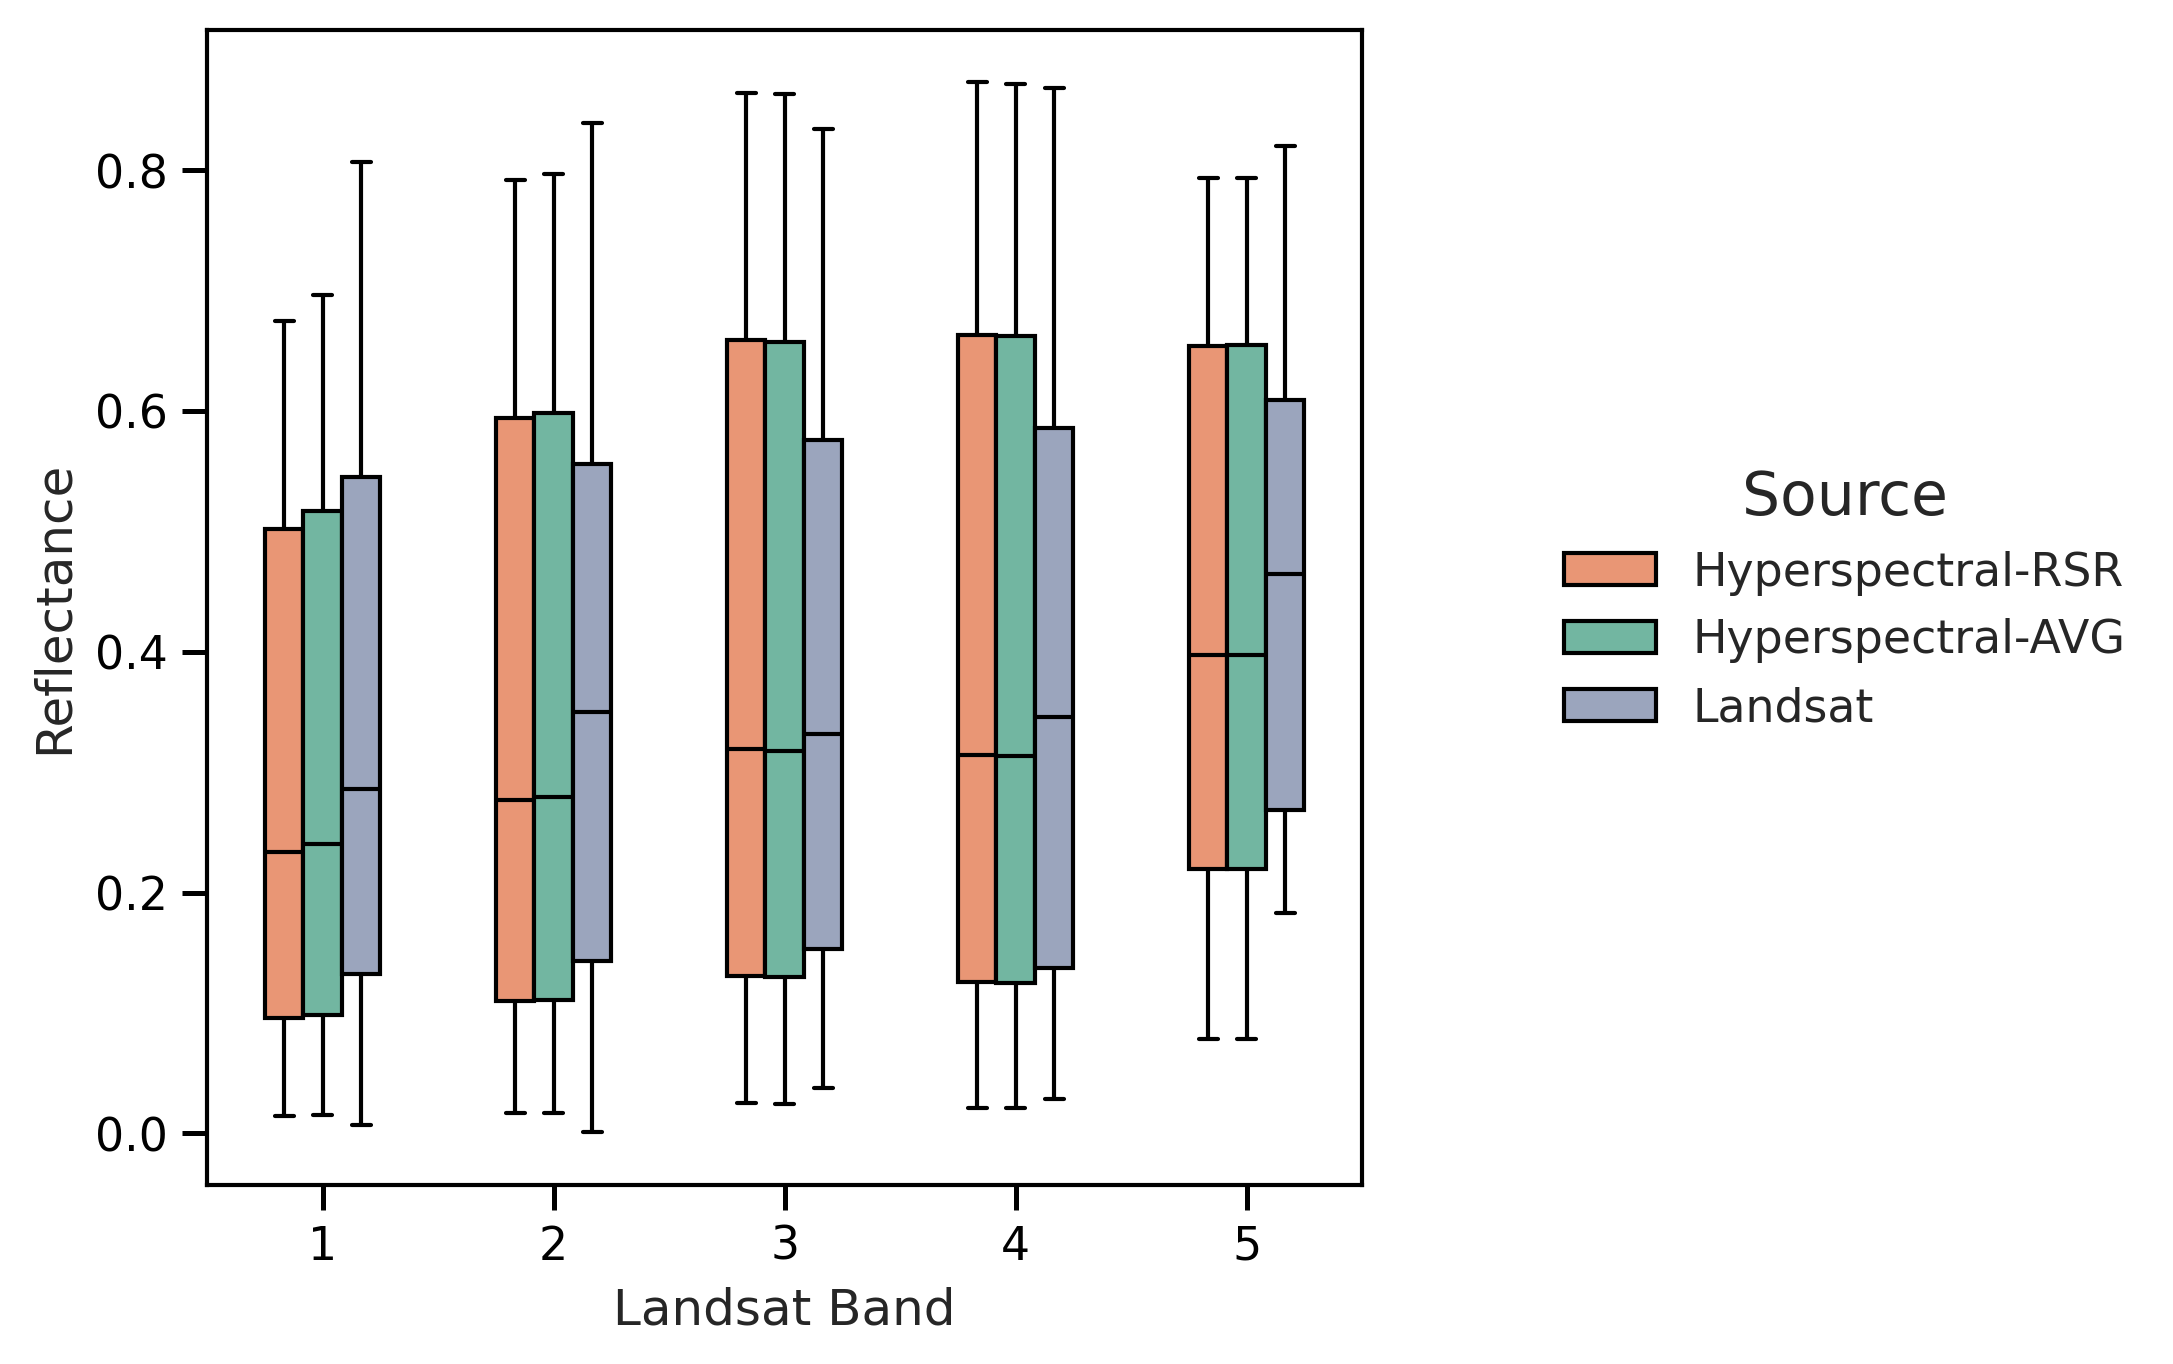

✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/pika_L/reflectance_comparison_mixed.png


In [8]:
# 4. Reflectance difference
# 4.1. Pika L
hs_pika_L, ms_landsat_pika_L = calculate_multiband_reflectance_differences(
    gpkg_path=grid_processed,
    geotiff_folder=reflectance_rsr_pl,  
    landsat_path=landsat_path,
    output_folder=os.path.join(output_rsr, 'pika_L'),
    study_site=place,
    sensor="pika l",
    landsat_image=landsat_filename,
    landsat_version="8",  
    valid_pixel_tolerance=60
)

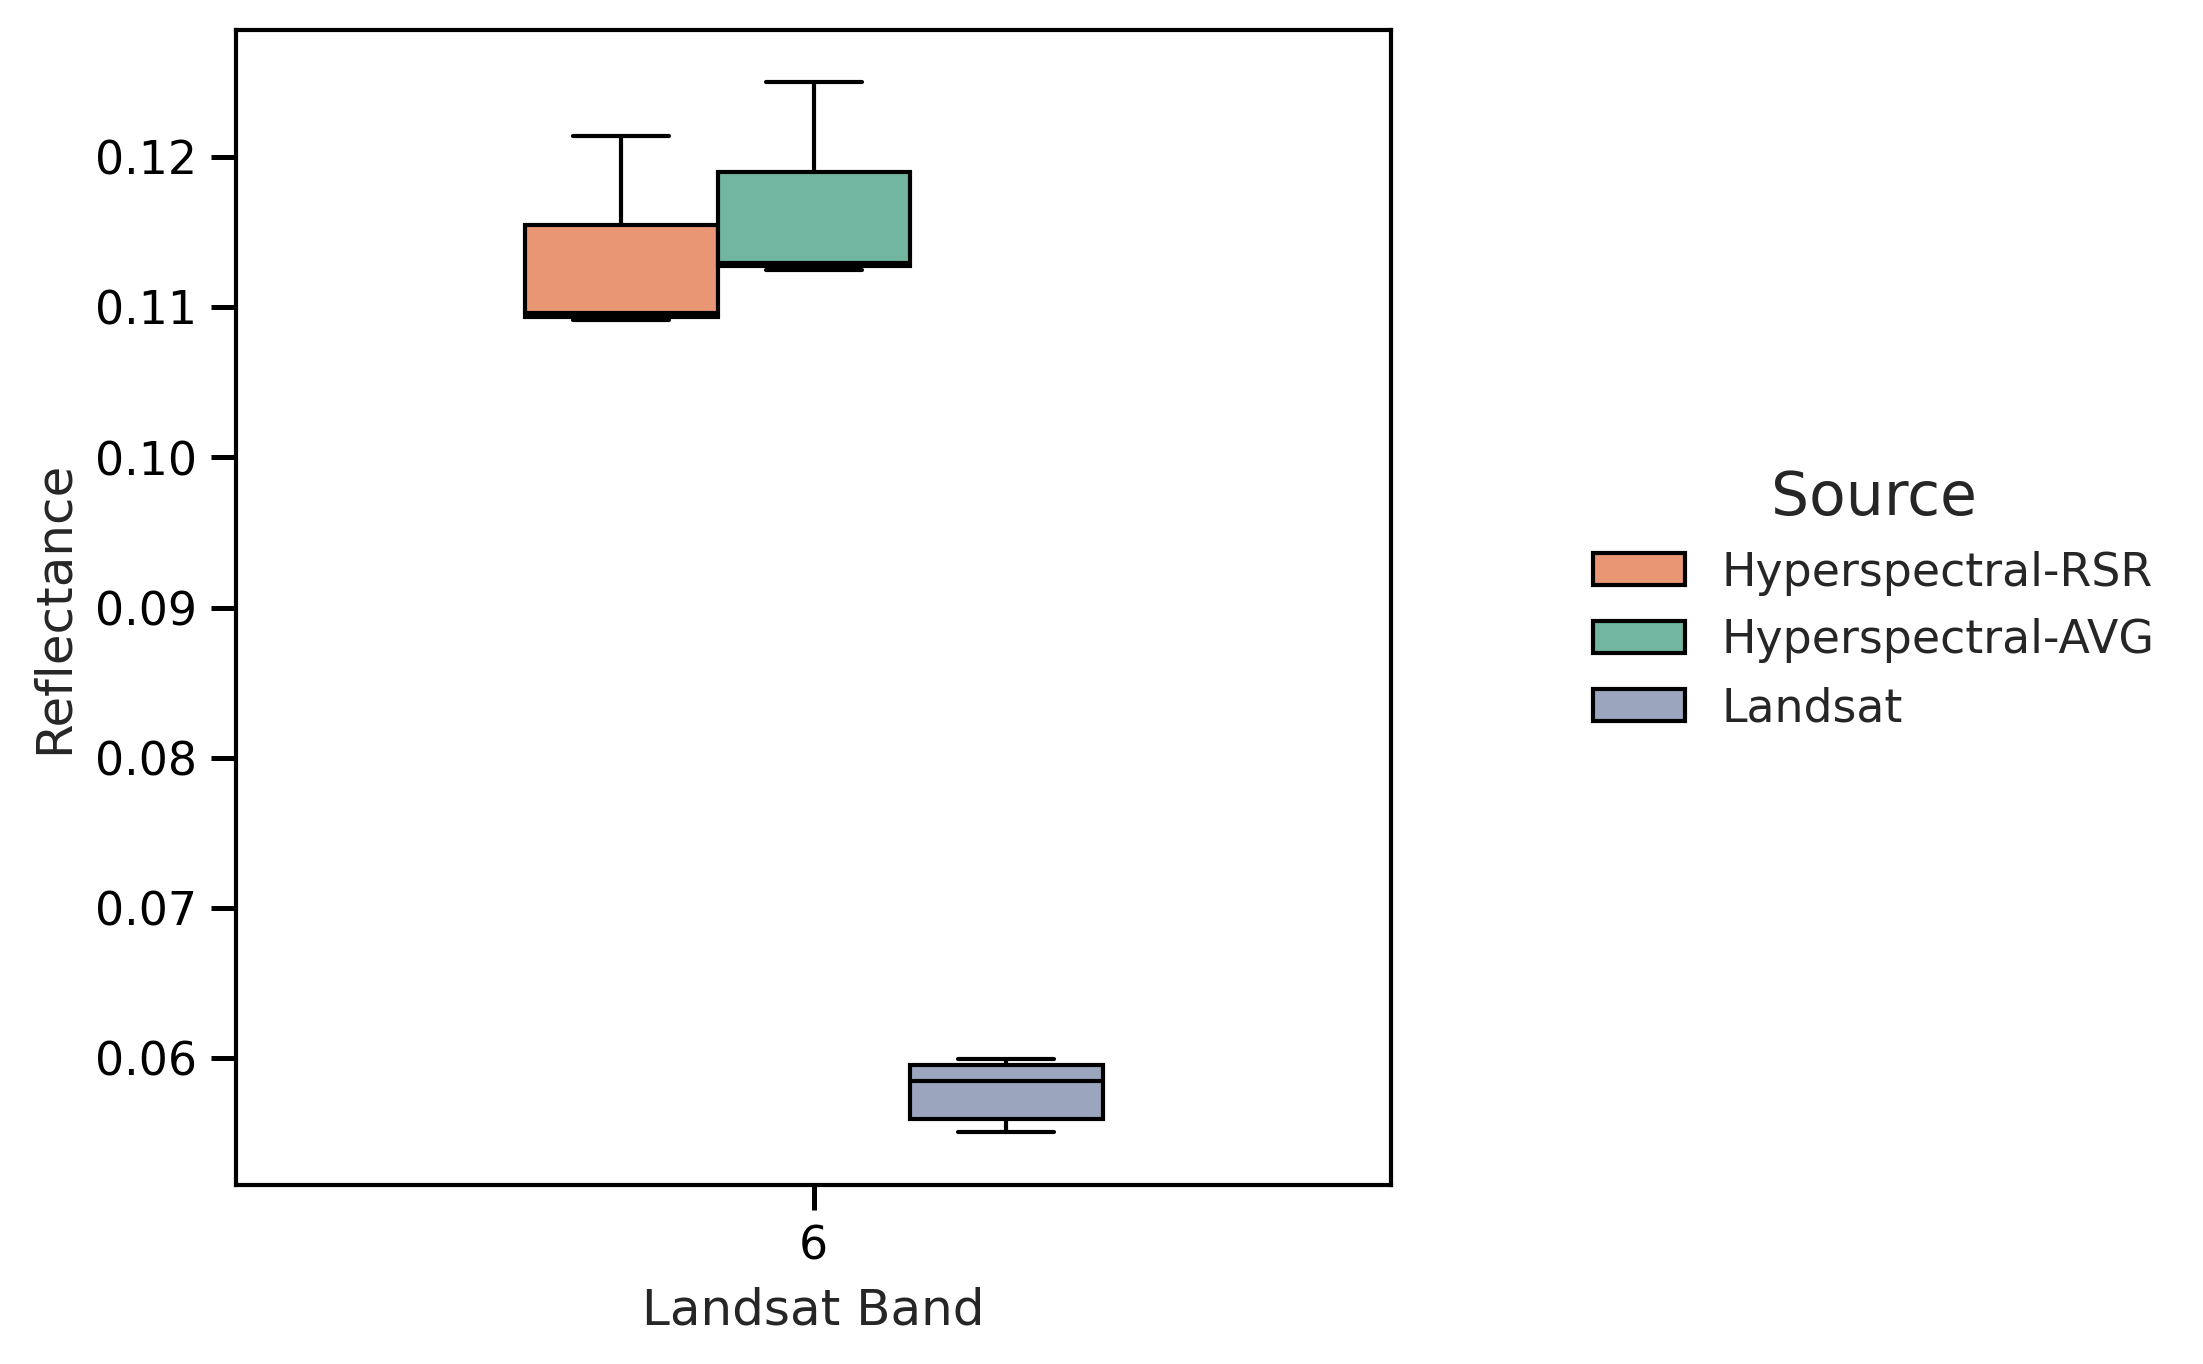

✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/pika_IRL/reflectance_comparison_snow.png


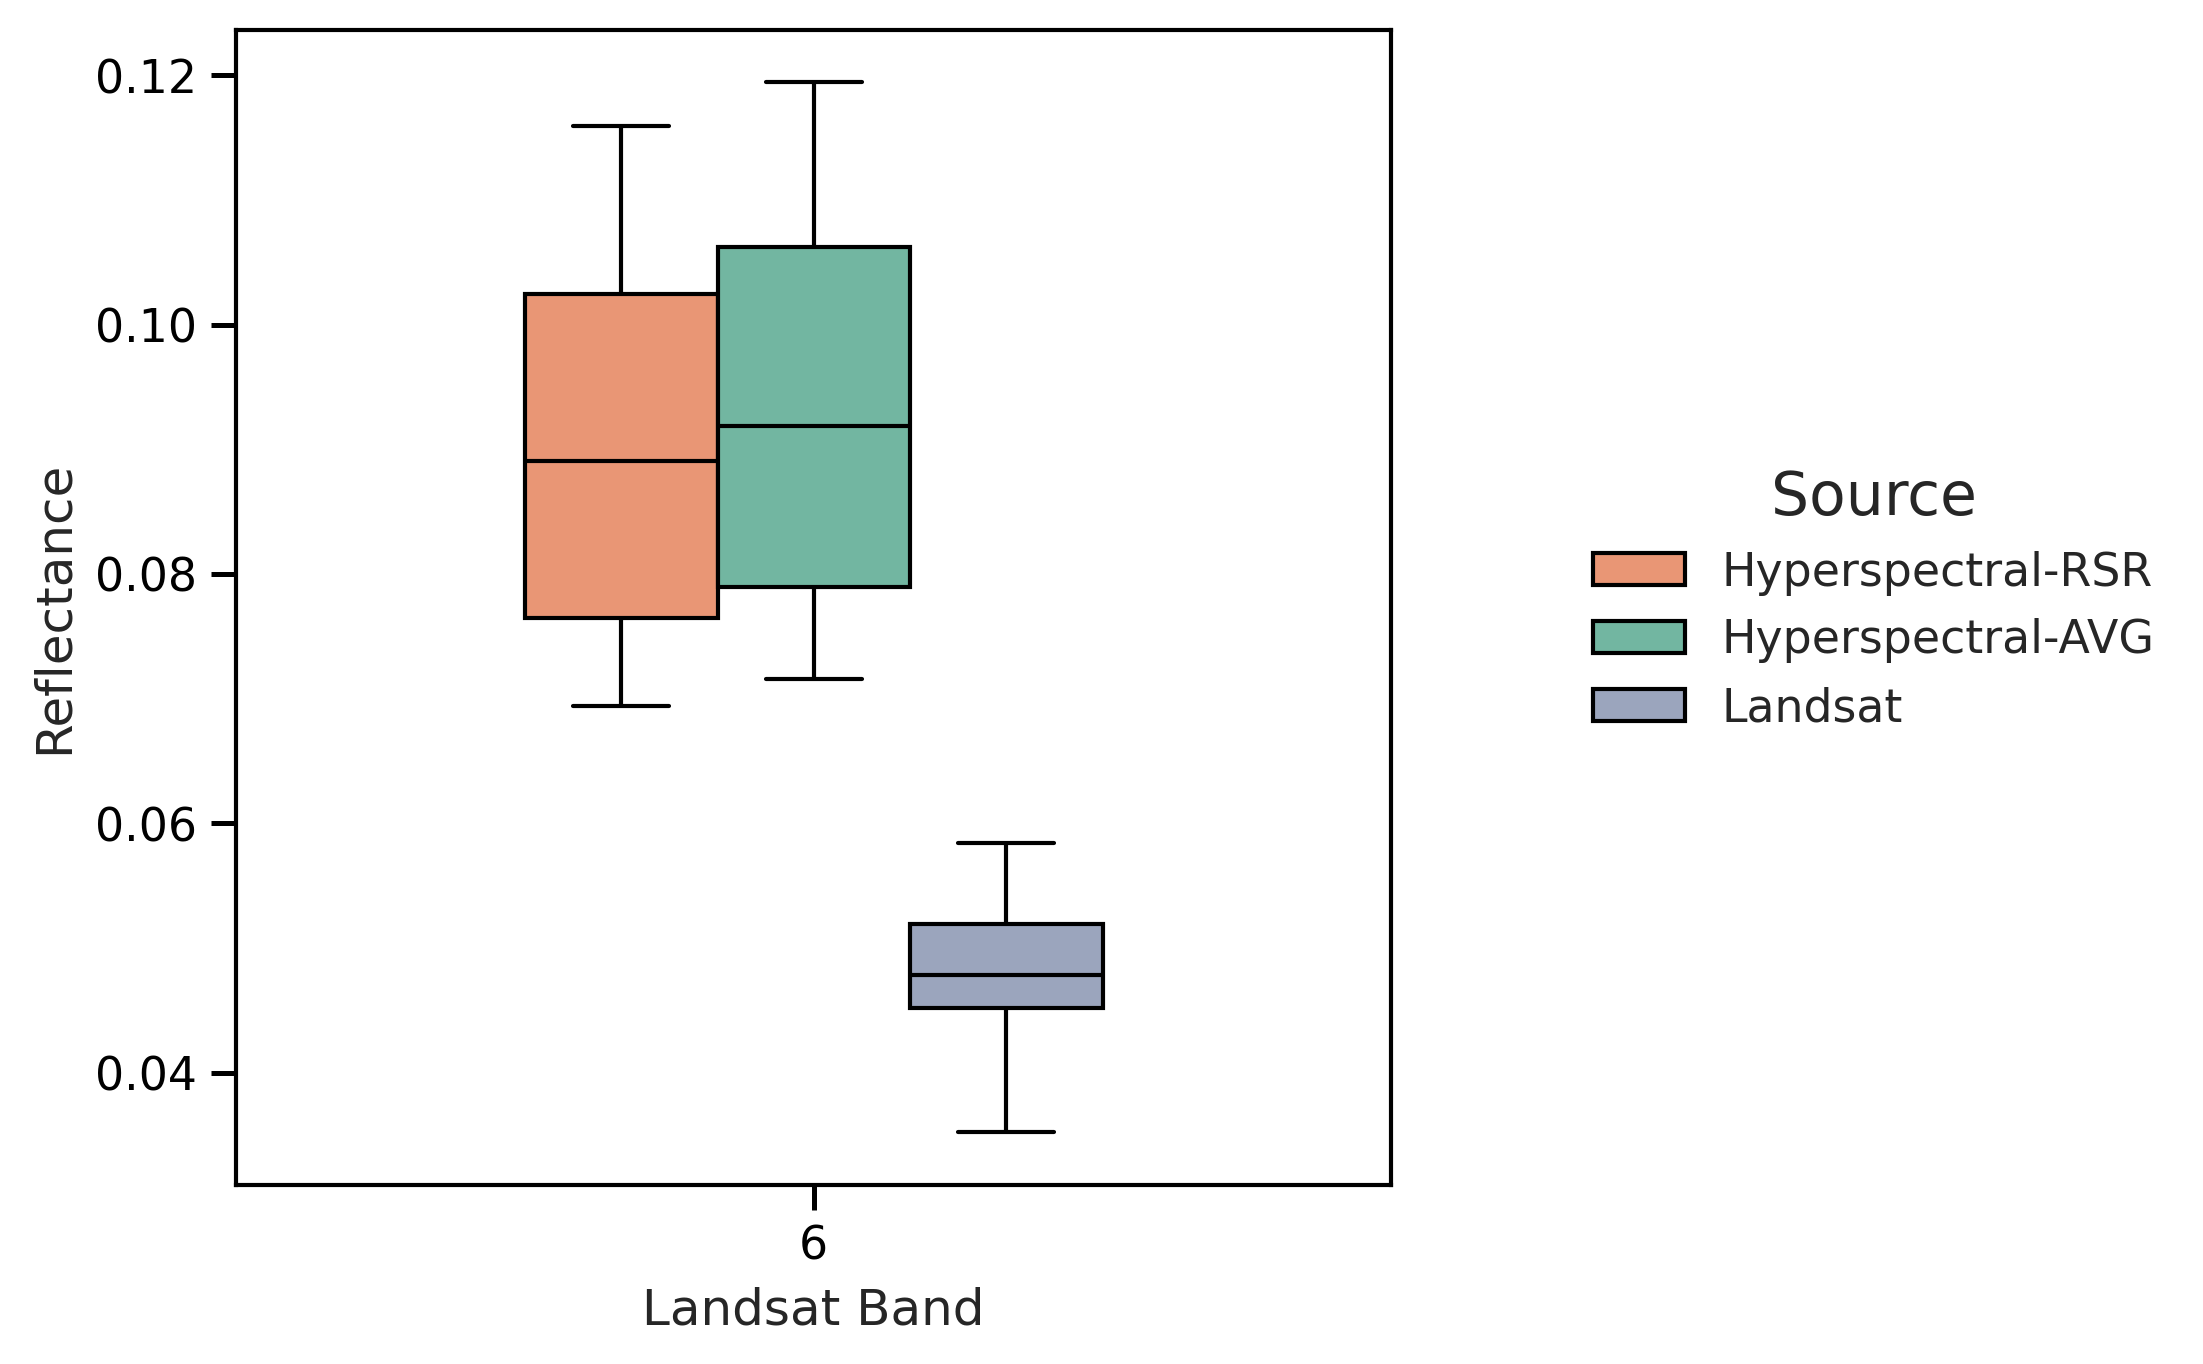

✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/pika_IRL/reflectance_comparison_mixed.png


In [10]:
# 4.2. Pika IRL

hs_pika_IRL, ms_landsat_pika_IRL = calculate_multiband_reflectance_differences(
    gpkg_path=grid_processed,
    geotiff_folder=reflectance_rsr_pirl,  
    landsat_path=landsat_path,
    output_folder=os.path.join(output_rsr, 'pika_IRL'),
    study_site=place,
    sensor="pika irl",
    landsat_image=landsat_filename,
    landsat_version="8", 
    valid_pixel_tolerance=60
)


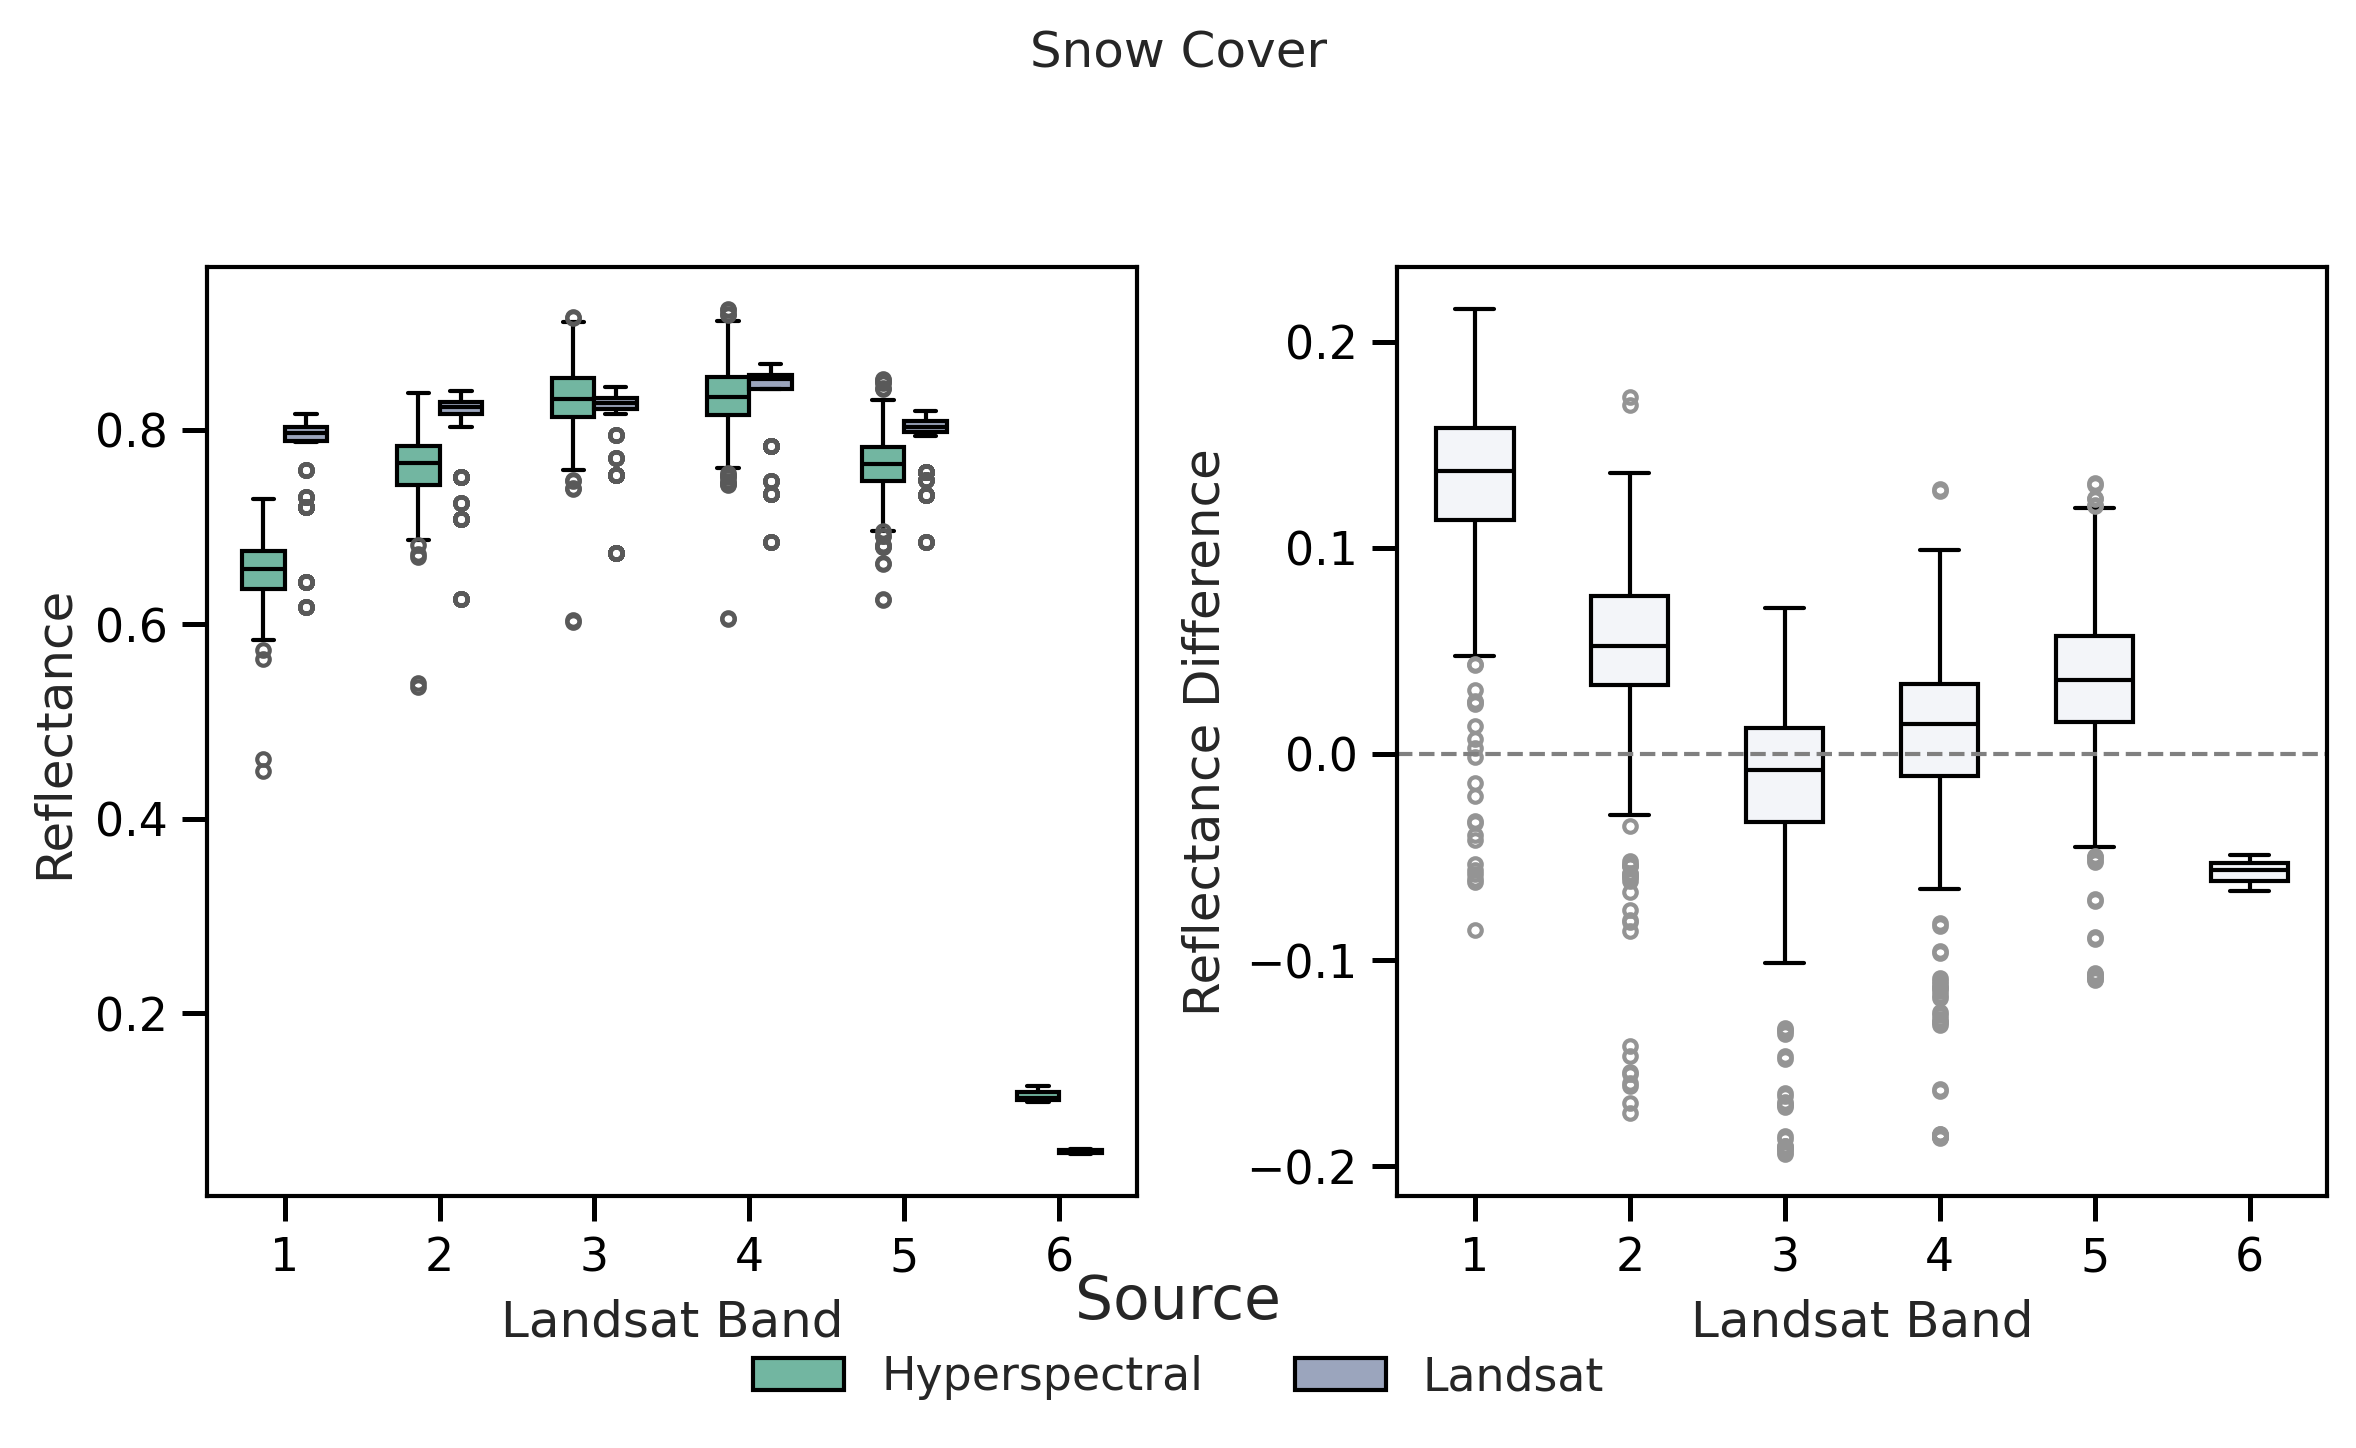

✅ Plot saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/reflectance_difference_snow.png


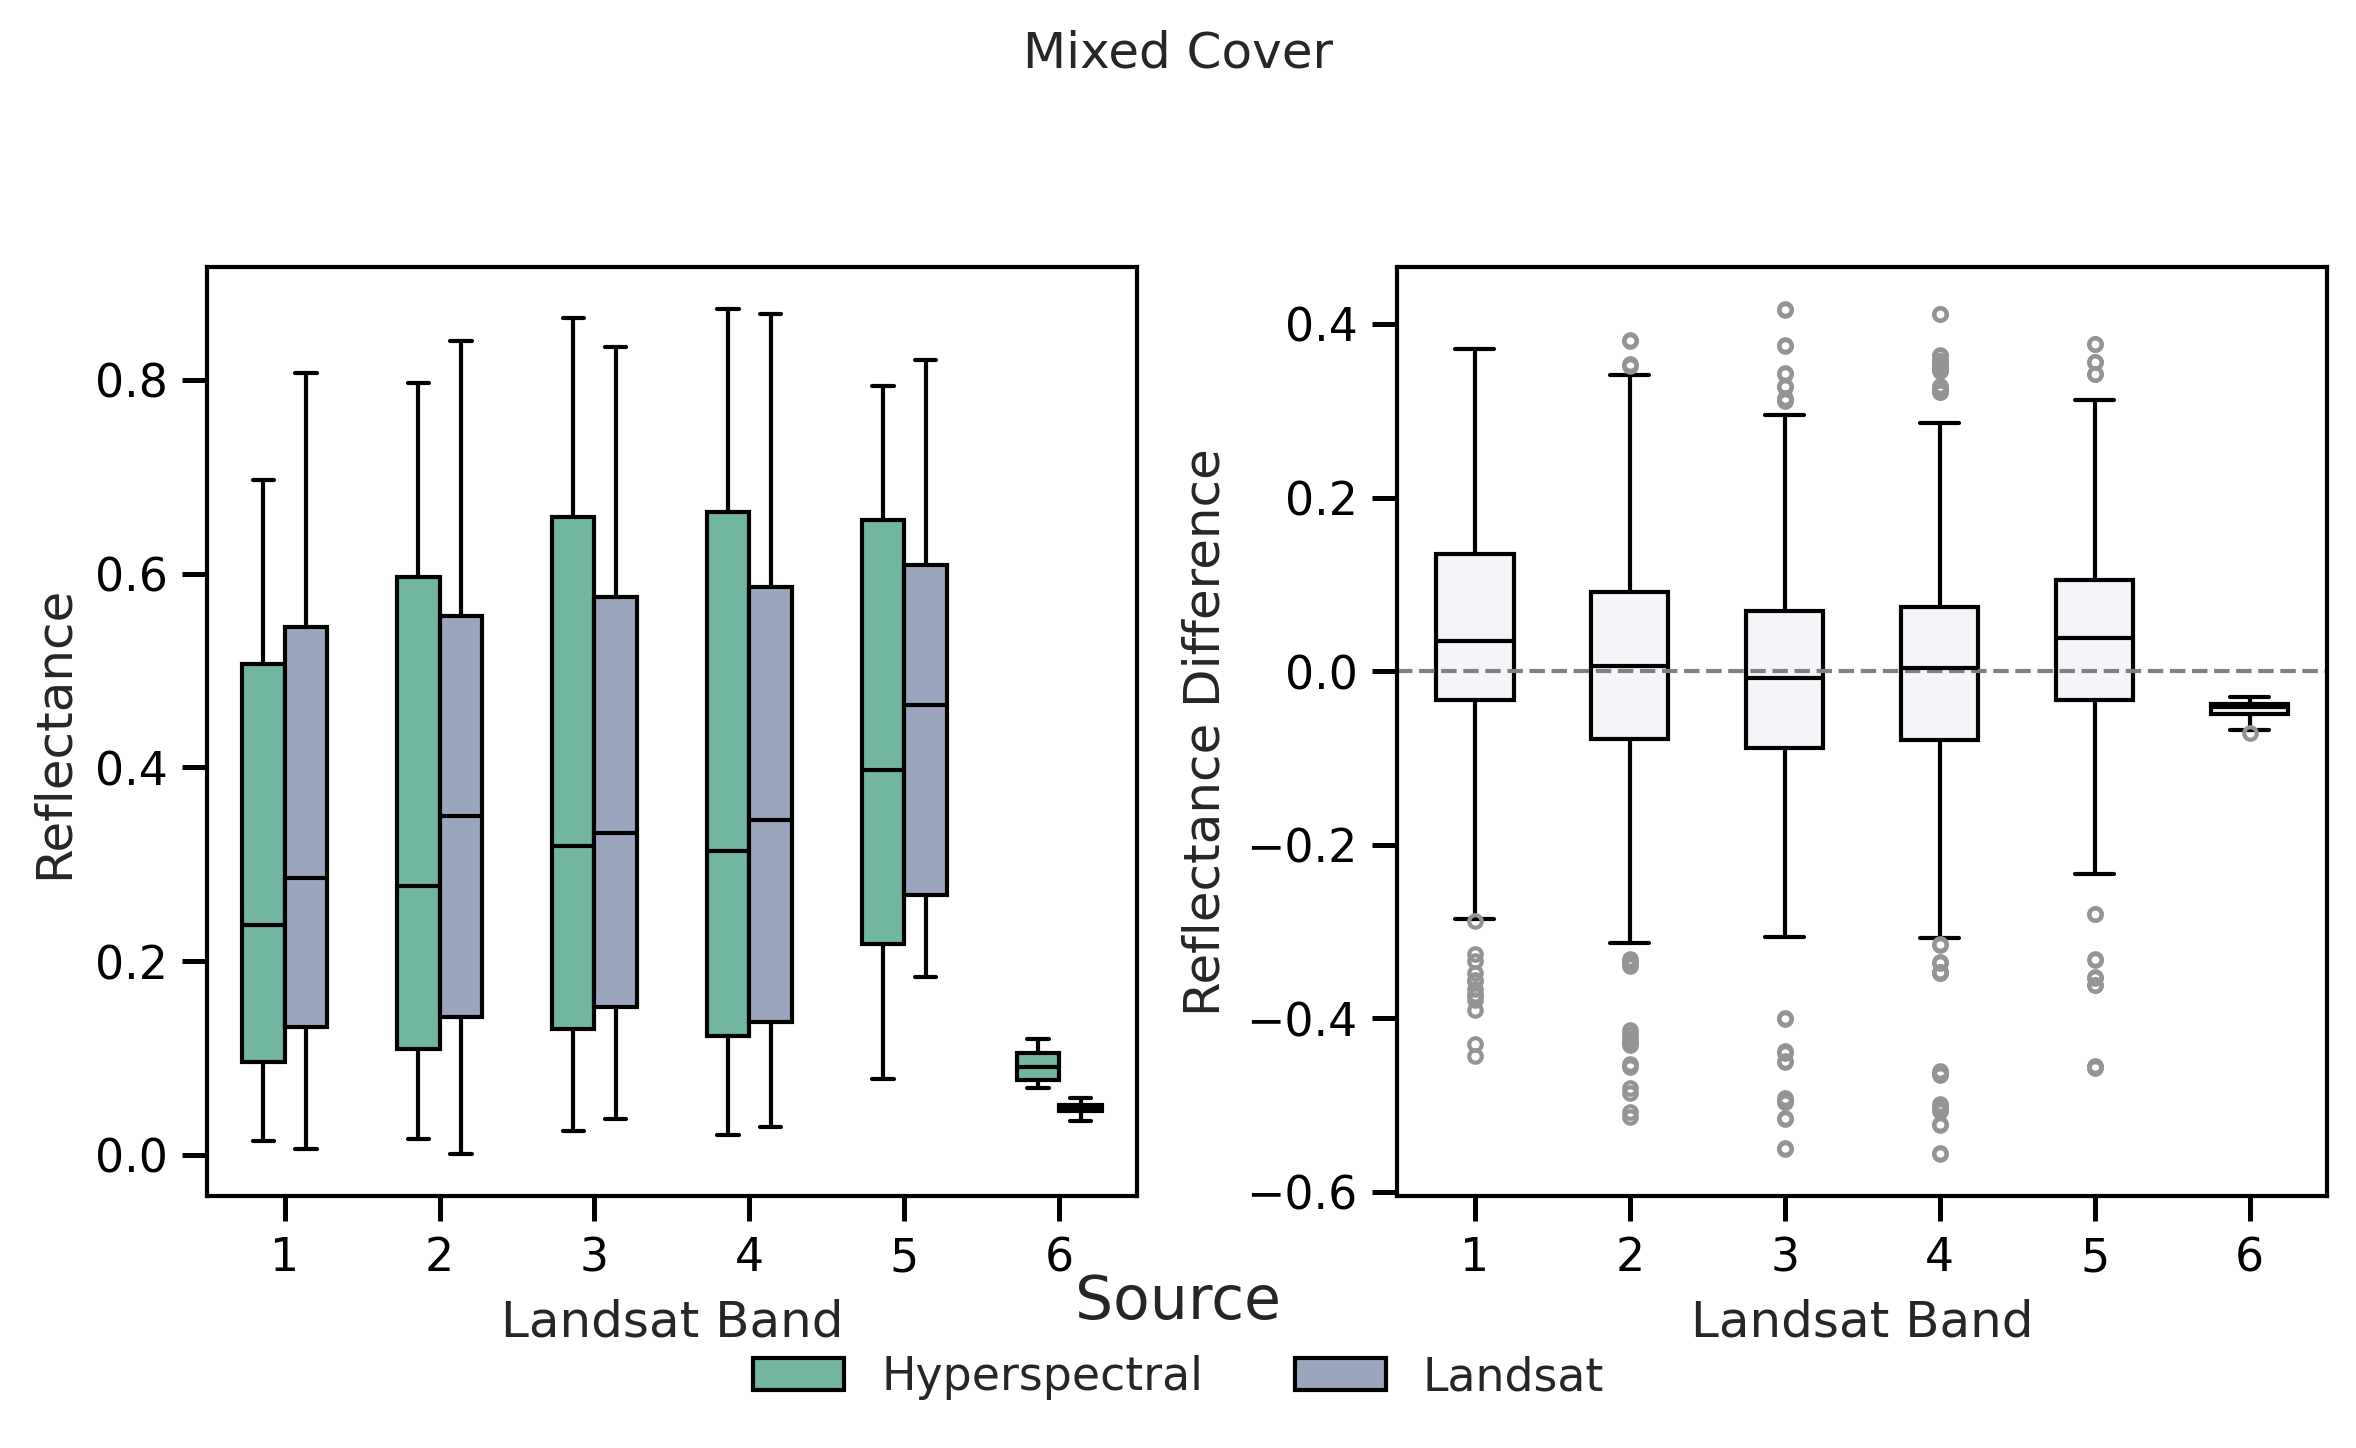

✅ Plot saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/reflectance_difference_mixed.png


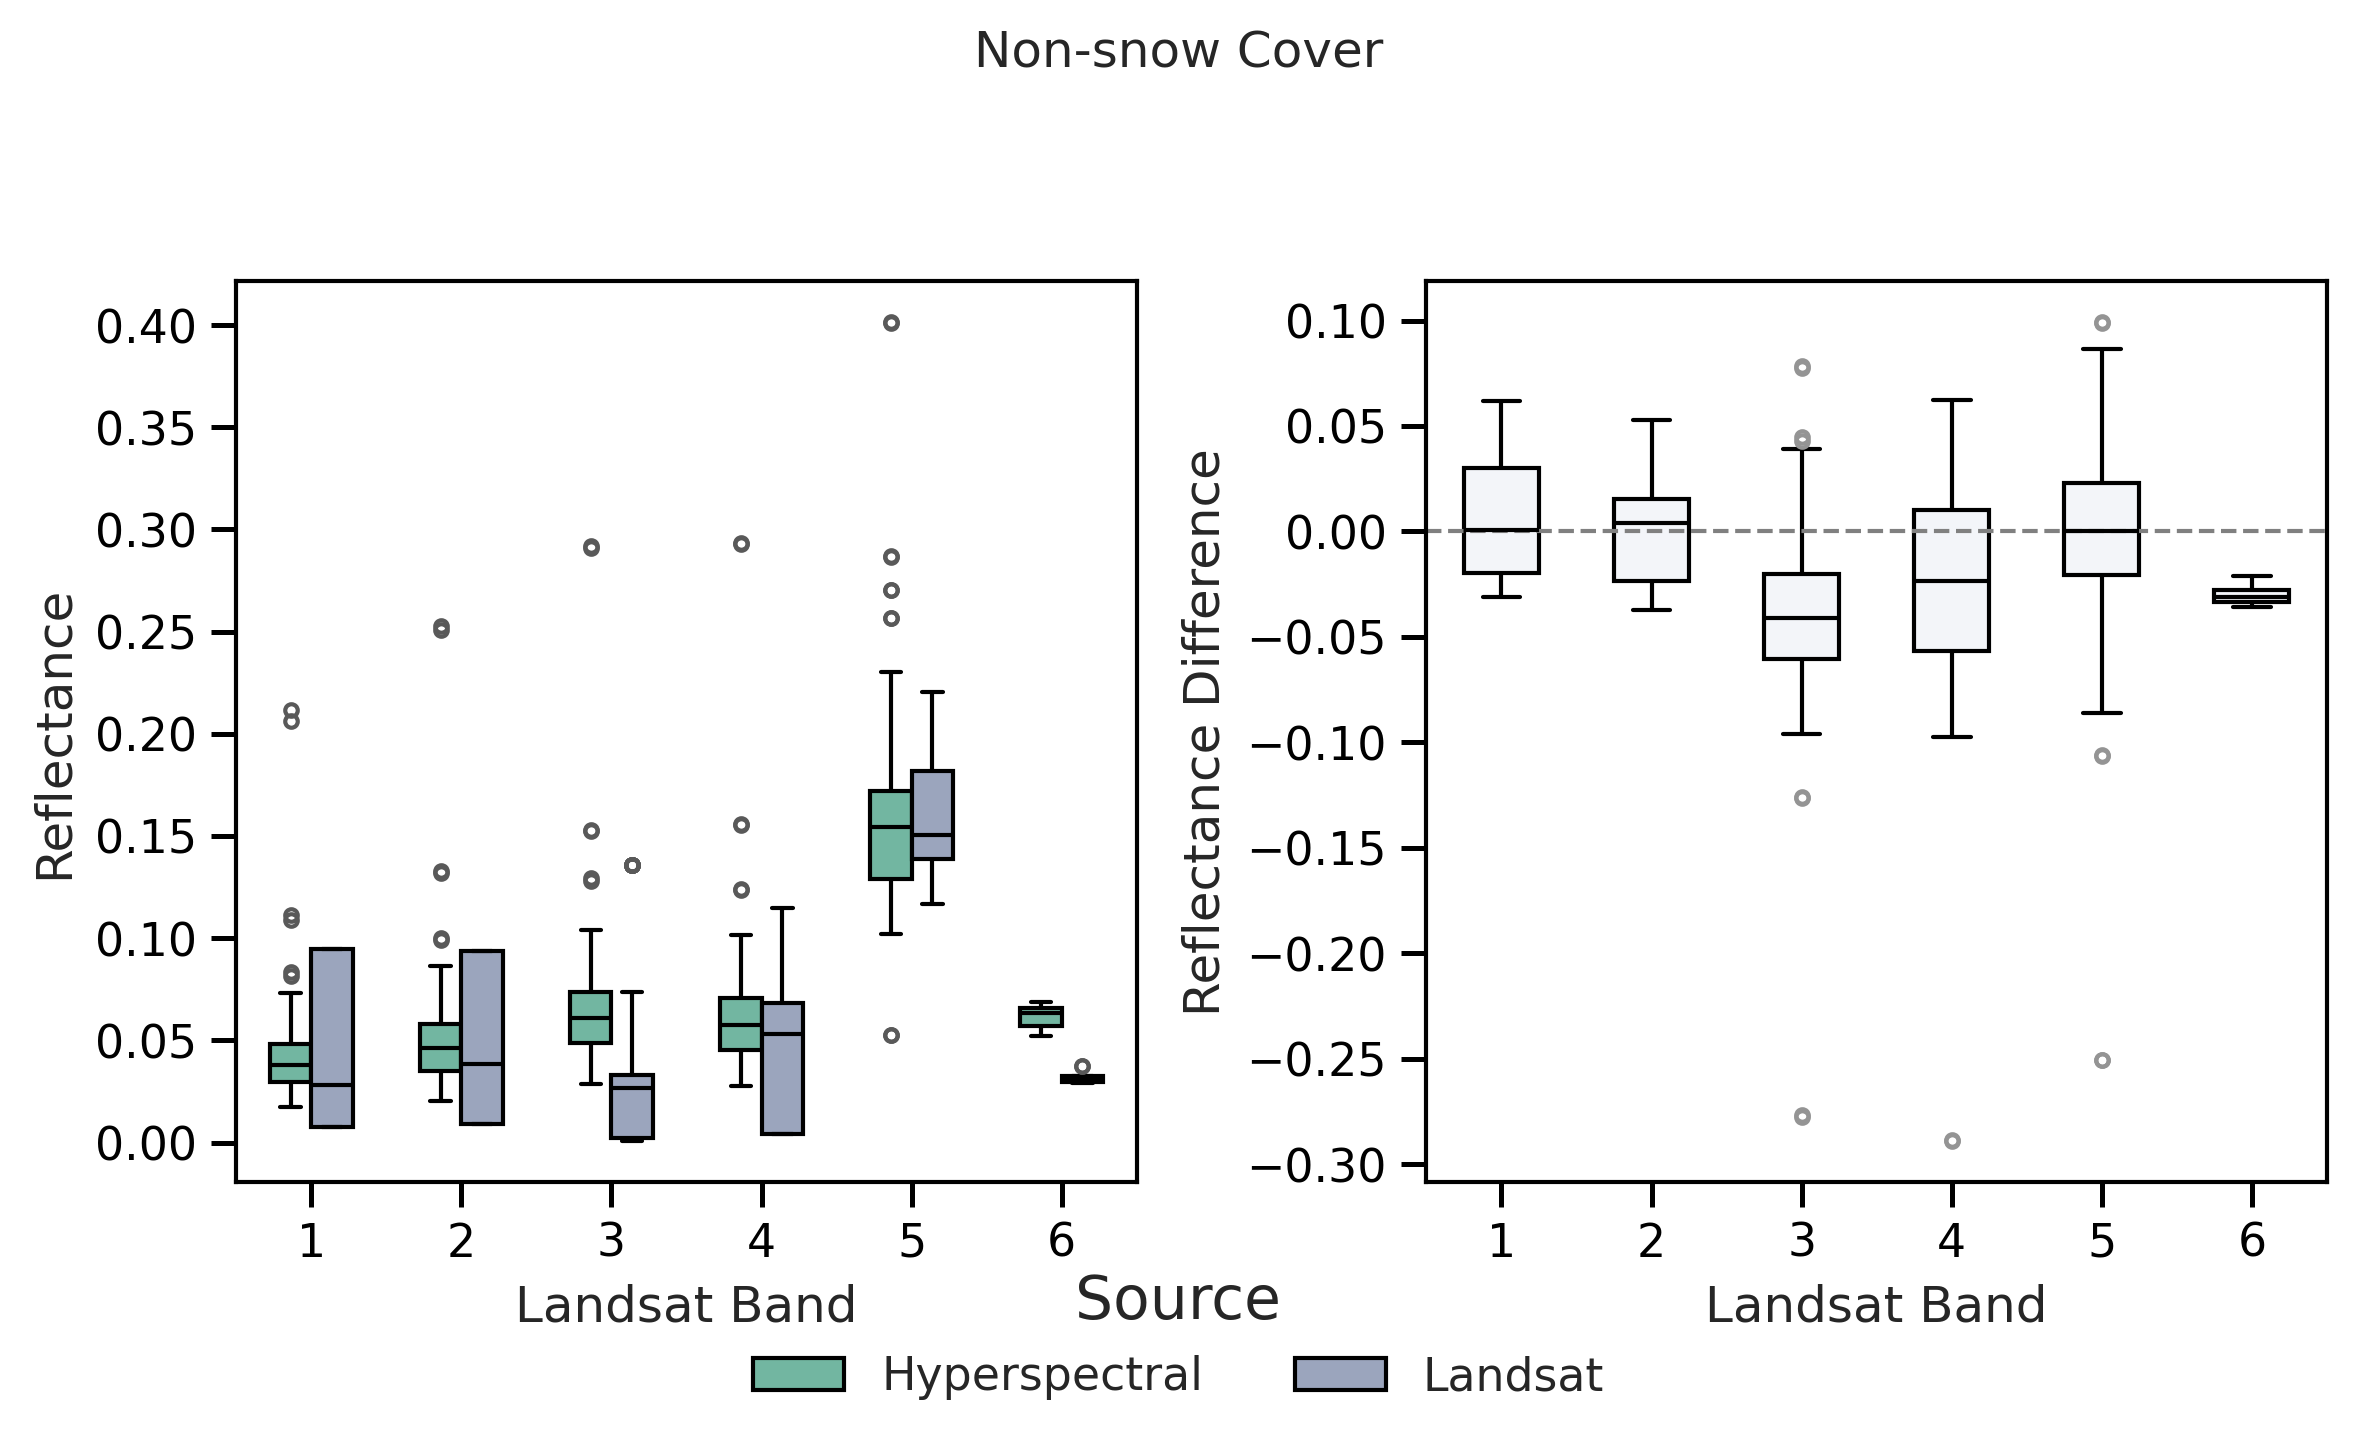

✅ Plot saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240420_Onion/reflectance_difference_none.png


In [11]:
# 4.3.b Reflectance difference for Pika L and Pika IR-L
plot_reflectance_and_differences_by_pixel_type(
    hs_pika_L=hs_pika_L,
    ms_landsat_pika_L=ms_landsat_pika_L,
    hs_pika_IRL=hs_pika_IRL,
    ms_landsat_pika_IRL=ms_landsat_pika_IRL,
    output_folder=output_rsr
)

### Convert hypercubes into geotiff

In [24]:
# 4.3.b Reflectance difference for Pika L and Pika IR-L
plot_reflectance_and_differences_by_pixel_type_IRL(
    hs_pika_IRL=hs_pika_IRL,
    ms_landsat_pika_IRL=ms_landsat_pika_IRL,
    output_folder=output_rsr
)

✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240403_Sodankyla/snow_reflectance_normal_4cm.png
✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240403_Sodankyla/snow_difference_normal_4cm.png
✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240403_Sodankyla/snow_reflectance_nolabel_4cm.png
✅ Saved: /path/to/snow_albedo/04_products/01_reflectance_multiband_difference/20240403_Sodankyla/snow_difference_nolabel_4cm.png


#### Part 2: HSI Classification

#### Pika L

Extracting training data...
Found 1 unique cubes for training.
Applying PCA...
Balancing data...
Splitting dataset...
Training CNN...
Epoch 1/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7577 - loss: 0.6042 - val_accuracy: 0.5729 - val_loss: 0.9963
Epoch 2/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9509 - loss: 0.1525 - val_accuracy: 0.9909 - val_loss: 0.0230
Epoch 3/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9675 - loss: 0.0951 - val_accuracy: 0.9905 - val_loss: 0.0347
Epoch 4/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9742 - loss: 0.0800 - val_accuracy: 0.9936 - val_loss: 0.0135
Epoch 5/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9743 - loss: 0.0758 - val_accuracy: 0.9946 - val_loss: 0.0130
Epoch 6/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9763 - loss: 0.0719 - val_accuracy: 0.9909 - val_loss: 0.0245
Epoch 7/50
322/322 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9686 - loss: 0.1024 - val_accura

Saving model and performance...
✅ Done.


Loading model and PCA...
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_16_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_17_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_18_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_19_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_20_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Onion_MT/20240420_PIL/02_geotiff/01_reflectance/20240420_Onion_21_PIL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercube

Processing reflectance files: 100%|██████████| 47/47 [01:02<00:00,  1.33s/it]



✅ Summary saved: /path/to/snow_albedo/04_products/02_classificated_reflectance/20240420_Onion_Park/pika_L/hsi/summary.csv


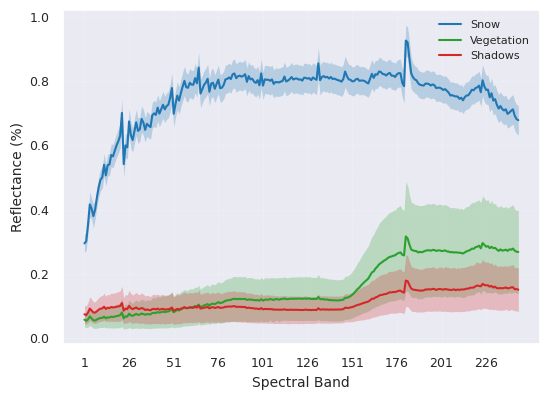

✅ Cumulative plot saved.


In [12]:
# Training Model for Pika L
model, pca, (X_test, y_test, y_pred) = train_strict_cnn_from_polygons(
    gdf_path=training_polygons_pl,
    raster_folder=reflectance_raster_pl,
    output_folder=output_training_pl,
    cube_column="cube",
    label_column="type",
    pca_components=20,
    epochs=50
)

classify_and_vectorize_cubes(
    input_folder=reflectance_raster_pl,
    output_folder=output_classification_pl,
    model_path=output_training_pl+"/cnn_model.h5",
    pca_path=output_training_pl+"/pca_model.pkl"
)

compute_reflectance_statistics(
    reflectance_folder=reflectance_raster_pl,
    gpkg_folder=gpkg_classified_pl,
    output_csv_folder=output_classification_product_pl+'/hsi/',
    output_plot_folder=output_classification_product_pl+'/hsi/',
    summary_csv_path=output_classification_product_pl+'/hsi/summary.csv'
)

#### Pika IR-L

In [ ]:
# Training Model for Pika IRL
model, pca, (X_test, y_test, y_pred) = train_strict_cnn_from_polygons(
    gdf_path=training_polygons_pirl,
    raster_folder=reflectance_raster_pirl,
    output_folder=output_training_pirl,
    cube_column="cube",
    label_column="type",
    pca_components=20,
    epochs=50
)

Extracting training data...
Found 1 unique cubes for training.
Applying PCA...
Balancing data...
Splitting dataset...
Training CNN...
Epoch 1/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.8576 - loss: 0.4862 - val_accuracy: 0.9781 - val_loss: 0.1698
Epoch 2/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9773 - loss: 0.1058 - val_accuracy: 0.9777 - val_loss: 0.0822
Epoch 3/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9752 - loss: 0.1024 - val_accuracy: 0.9772 - val_loss: 0.0844
Epoch 4/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9759 - loss: 0.1015 - val_accuracy: 0.9790 - val_loss: 0.0802
Epoch 5/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9787 - loss: 0.0866 - val_accuracy: 0.9795 - val_loss: 0.0781
Epoch 6/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9750 - loss: 0.0964 - val_accuracy: 0.9781 - val_loss: 0.0829
Epoch 7/50
327/327 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9806 - loss: 0.0810 - val_accura

ERROR 1: PROJ: proj_create_from_database: /path/to/home/.conda/envs/spectral/lib/python3.12/site-packages/rasterio/proj_data/proj.db contains DATABASE.LAYOUT.VERSION.MINOR = 2 whereas a number >= 3 is expected. It comes from another PROJ installation.


Extracting training data...
Found 1 unique cubes for training.
Applying PCA...
Balancing data...
Splitting dataset...
Training CNN...
Epoch 1/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 4s 1ms/step - accuracy: 0.8338 - loss: 0.4795 - val_accuracy: 0.9776 - val_loss: 0.0729
Epoch 2/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9636 - loss: 0.1160 - val_accuracy: 0.9895 - val_loss: 0.0374
Epoch 3/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9680 - loss: 0.1027 - val_accuracy: 0.9907 - val_loss: 0.0331
Epoch 4/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9682 - loss: 0.0990 - val_accuracy: 0.9835 - val_loss: 0.0579
Epoch 5/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9706 - loss: 0.0914 - val_accuracy: 0.9905 - val_loss: 0.0318
Epoch 6/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9729 - loss: 0.0860 - val_accuracy: 0.9892 - val_loss: 0.0315
Epoch 7/50
1972/1972 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9717 - loss: 0.085

Saving model and performance...


✅ Done.
Loading model and PCA...
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_1_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_2_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_3_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_4_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_5_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01_processed_hypercubes/2024_Greenland/Greenland/02_geotiff/01_reflectance/20240630_Greenland_6_PIRL.tiff
Processing /path/to/snow_albedo/03_incremental/01

Processing reflectance files: 100%|██████████| 7/7 [01:06<00:00,  9.49s/it]



✅ Summary saved: /path/to/snow_albedo/04_products/02_classificated_reflectance/20240630_greenland/pika_IRL/hsi/summary.csv


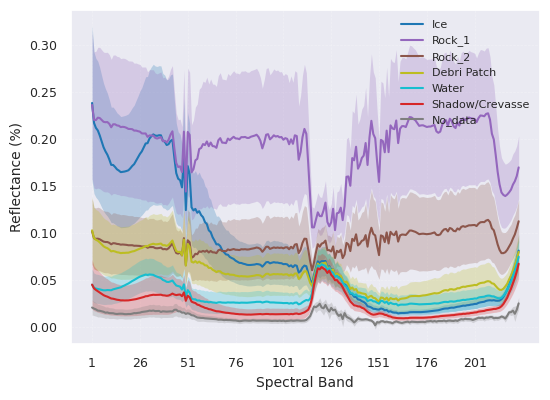

✅ Cumulative plot saved.


In [3]:
# Training Model for Pika IRL
model, pca, (X_test, y_test, y_pred) = train_strict_cnn_from_polygons(
    gdf_path=training_polygons_pirl,
    raster_folder=reflectance_raster_pirl,
    output_folder=output_training_pirl,
    cube_column="cube",
    label_column="type",
    pca_components=20,
    epochs=50
)

classify_and_vectorize_cubes(
    input_folder=reflectance_raster_pirl,
    output_folder=output_classification_pirl,
    model_path=output_training_pirl+"/cnn_model.h5",
    pca_path=output_training_pirl+"/pca_model.pkl"
)

compute_reflectance_statistics(
    reflectance_folder=reflectance_raster_pirl,
    gpkg_folder=gpkg_classified_pirl,
    output_csv_folder=output_classification_product_pirl+'/hsi/',
    output_plot_folder=output_classification_product_pirl+'/hsi/',
    summary_csv_path=output_classification_product_pirl+'/hsi/summary.csv'
)

Processing reflectance files: 100%|██████████| 47/47 [00:11<00:00,  3.99it/s]


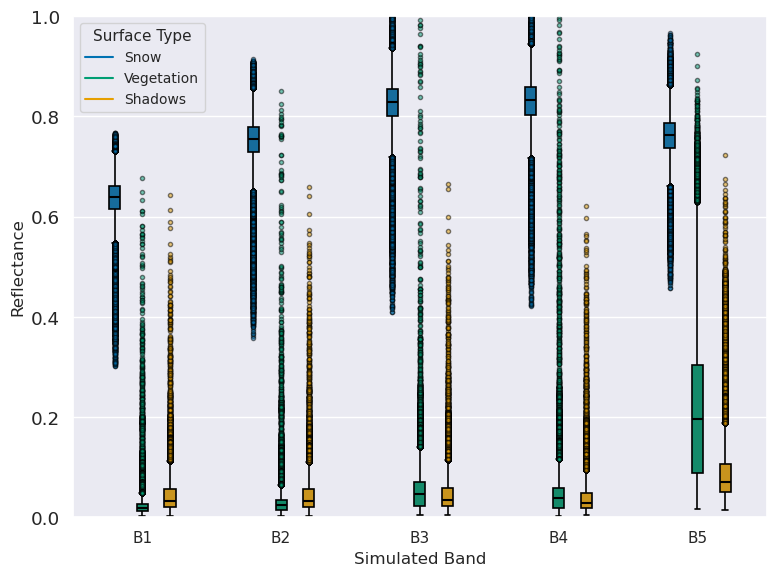

(                                                  file  band    class  \
 0    20240420_onion_crns_Pika_L_46-Georectify Airbo...     1     Snow   
 1    20240420_onion_crns_Pika_L_46-Georectify Airbo...     2     Snow   
 2    20240420_onion_crns_Pika_L_46-Georectify Airbo...     3     Snow   
 3    20240420_onion_crns_Pika_L_46-Georectify Airbo...     4     Snow   
 4    20240420_onion_crns_Pika_L_46-Georectify Airbo...     5     Snow   
 ..                                                 ...   ...      ...   
 685  20240420_onion_crns_Pika_L_60-Georectify Airbo...     1  Shadows   
 686  20240420_onion_crns_Pika_L_60-Georectify Airbo...     2  Shadows   
 687  20240420_onion_crns_Pika_L_60-Georectify Airbo...     3  Shadows   
 688  20240420_onion_crns_Pika_L_60-Georectify Airbo...     4  Shadows   
 689  20240420_onion_crns_Pika_L_60-Georectify Airbo...     5  Shadows   
 
          mean       std       min       max       Q25       Q50       Q75  
 0    0.657272  0.024535  0.59058

In [13]:
# Reflectance difference for bands
# Pika L
compute_reflectance_statistics_rsr(
    reflectance_folder=reflectance_rsr_pl+'/landsat8/',
    gpkg_folder=gpkg_classified_pl,
    output_csv_folder=output_classification_product_pl + '/bands/landsat8',
    output_plot_folder=output_classification_product_pl + '/bands/landsat8',
    summary_csv_path=output_classification_product_pl + '/bands/landsat8/summary_rsr.csv',
    sensor="Pika L"
)

Processing reflectance files: 100%|██████████| 8/8 [00:00<00:00, 13.92it/s]


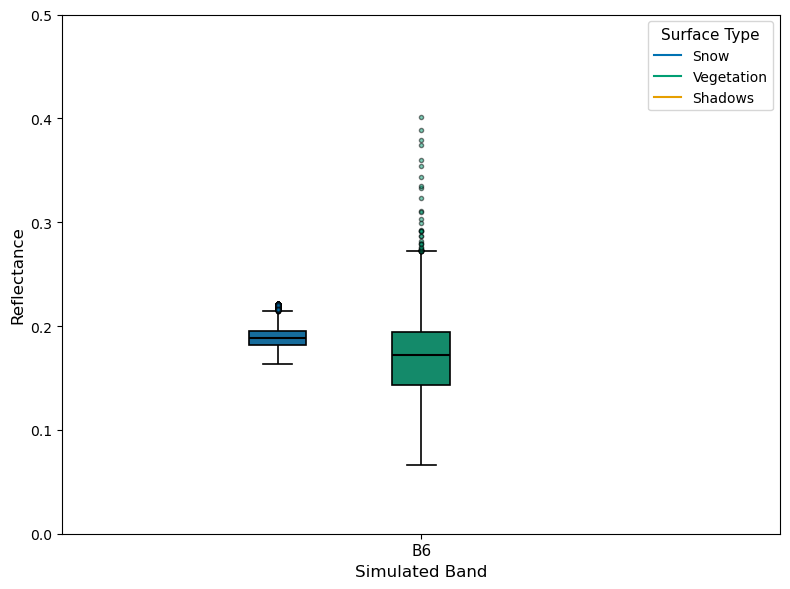

(                                             file  band       class      mean  \
 0   20240216_carc_Pika IR L_1.bil_Landsat8_B6_AVG     6        Snow  0.181875   
 1   20240216_carc_Pika IR L_1.bil_Landsat8_B6_AVG     6  Vegetation  0.169685   
 2  20240216_carc_Pika IR L_11.bil_Landsat8_B6_AVG     6        Snow  0.190476   
 3  20240216_carc_Pika IR L_11.bil_Landsat8_B6_AVG     6  Vegetation  0.284793   
 4  20240216_carc_Pika IR L_13.bil_Landsat8_B6_AVG     6        Snow  0.189279   
 5  20240216_carc_Pika IR L_13.bil_Landsat8_B6_AVG     6  Vegetation  0.171815   
 6  20240216_carc_Pika IR L_10.bil_Landsat8_B6_AVG     6        Snow  0.196122   
 7  20240216_carc_Pika IR L_10.bil_Landsat8_B6_AVG     6  Vegetation  0.230019   
 8   20240216_carc_Pika IR L_7.bil_Landsat8_B6_AVG     6        Snow  0.193264   
 
         std       min       max       Q25       Q50       Q75  
 0  0.006375  0.163502  0.200856  0.177509  0.181169  0.186848  
 1  0.038510  0.065920  0.273182  0.143530  0.17

In [10]:
# Reflectance difference for bands
# Pika IRL
compute_reflectance_statistics_rsr(
    reflectance_folder=reflectance_rsr_pirl+'/avg/',
    gpkg_folder=gpkg_classified_pirl,
    output_csv_folder=output_classification_product_pirl + '/bands/avg',
    output_plot_folder=output_classification_product_pirl + '/bands/avg',
    summary_csv_path=output_classification_product_pirl + '/bands/avg/summary_rsr.csv',
    sensor="Pika IRL"
)

Processing reflectance files: 100%|██████████| 5/5 [00:01<00:00,  3.01it/s]


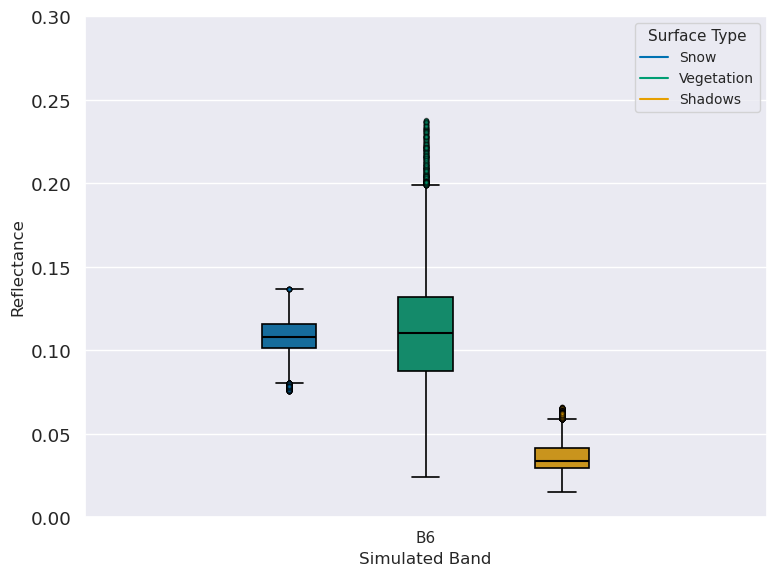

In [15]:
# Procesar Pika IRL
df_stats_irl, df_violin_irl = compute_reflectance_statistics_rsr(
    reflectance_folder=reflectance_rsr_pirl+'/landsat8/',
    gpkg_folder=gpkg_classified_pirl,
    output_csv_folder=output_classification_product_pirl + '/bands/landsat8',
    output_plot_folder=output_classification_product_pirl + '/bands/landsat8',
    summary_csv_path=output_classification_product_pirl + '/bands/landsat8/summary_rsr.csv',
    sensor="Pika IRL"
)


Processing reflectance files: 100%|██████████| 47/47 [00:11<00:00,  4.22it/s]


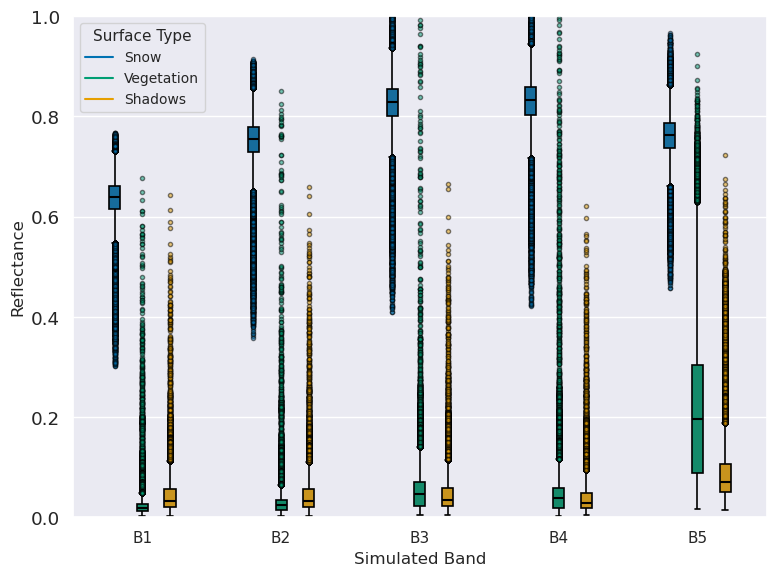

In [14]:
# Procesar Pika L
df_stats_pl, df_violin_pl = compute_reflectance_statistics_rsr(
    reflectance_folder=reflectance_rsr_pl+'/landsat8/',
    gpkg_folder=gpkg_classified_pl,
    output_csv_folder=output_classification_product_pl + '/bands/landsat8',
    output_plot_folder=output_classification_product_pl + '/bands/landsat8',
    summary_csv_path=output_classification_product_pl + '/bands/landsat8/summary_rsr.csv',
    sensor="Pika L"
)


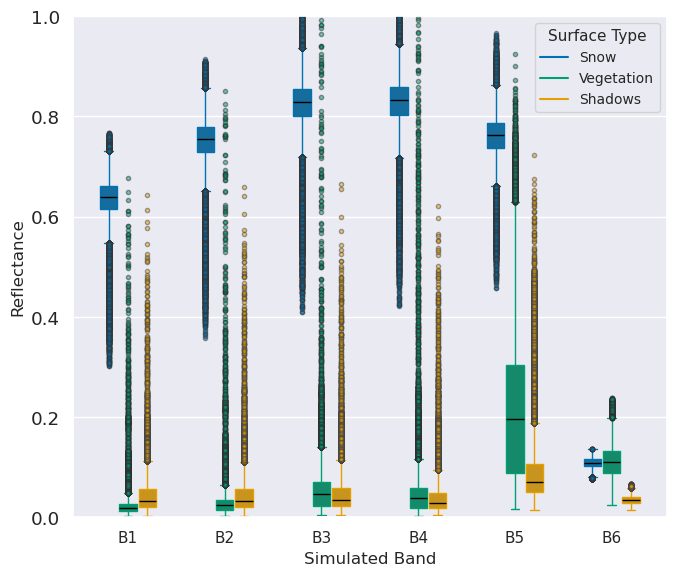

[INFO] ✅ Combined boxplot saved.


In [16]:


# Combinar resultados
df_stats_combined = pd.concat([df_stats_irl, df_stats_pl], ignore_index=True)
df_violin_combined = pd.concat([df_violin_irl, df_violin_pl], ignore_index=True)

# Guardar CSV combinado
summary_combined_path = "/path/to/snow_albedo/04_products/02_classificated_reflectance/20240420_Onion_Park/summary_rsr_combined.csv"
df_stats_combined.to_csv(summary_combined_path, index=False)

# Crear boxplot combinado
import matplotlib.pyplot as plt
import seaborn as sns

band_order = sorted(df_violin_combined["band"].unique(), key=lambda x: int(x[1:]))
class_order = list(color_map_custom.keys())

fig, ax = plt.subplots(figsize=(7, 6))
width = 0.2
offsets = {
    "Snow": -width,
    "Vegetation": 0,
    "Shadows": width
}

for cls in class_order:
    data_cls = df_violin_combined[df_violin_combined["class"] == cls]
    positions = [i + offsets[cls] for i in range(len(band_order))]
    sns.boxplot(
        data=data_cls,
        x="band",
        y="Reflectance (%)",
        order=band_order,
        ax=ax,
        positions=positions,
        width=width * 0.9,
        color=color_map_custom[cls],
        boxprops=dict(edgecolor=color_map_custom[cls]),
        whiskerprops=dict(color=color_map_custom[cls]),
        capprops=dict(color=color_map_custom[cls]),
        flierprops=dict(markerfacecolor=color_map_custom[cls], marker='o', alpha=0.5, markersize=3),
        medianprops=dict(color='black')
    )

ax.set_xticks(range(len(band_order)))
ax.set_xticklabels(band_order, fontsize=11)
ax.set_ylabel("Reflectance", fontsize=12)
ax.set_xlabel("Simulated Band", fontsize=12)

# Automatizar límite del eje Y
y_max = df_violin_combined["Reflectance (%)"].max()
y_max = np.ceil(y_max * 10) / 10
y_max = min(y_max, 1.0)
ax.set_ylim(0, y_max)

for cls in class_order:
    ax.plot([], [], color=color_map_custom[cls], label=cls)
ax.legend(title="Surface Type", fontsize=10, title_fontsize=11)

plt.tight_layout()
plt.savefig("/path/to/snow_albedo/04_products/02_classificated_reflectance/20240420_Onion_Park/summary_box_plot_combined.png", dpi=300)
plt.show()
print("[INFO] ✅ Combined boxplot saved.")